In [12]:
import torch
import torchvision
import numpy as np
from d2l import torch as d2l

from gen_sine_data import SineData
from utils import get_device

device = get_device()


In [2]:
train_data = SineData(True)
test_data = SineData(False)

20000
19900
100
<class 'torch.Tensor'>
torch.Size([19900, 100])
20000
19900
100
<class 'torch.Tensor'>
torch.Size([19900, 100])


15920 3980
torch.Size([15920, 100]) torch.Size([3980])
20000


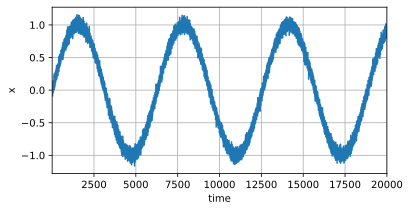

In [3]:
print(len(train_data), len(test_data))
print(train_data.features.shape, test_data.labels.shape)

time, x = SineData._gen_sine_data()

d2l.plot(time, x, 'time', 'x', xlim=[1, 20000], figsize=(6,3))

In [4]:
from simple_autoregressor import get_simple_autoregressor

model = get_simple_autoregressor()

20000
19900
100
<class 'torch.Tensor'>
torch.Size([19900, 100])
20000
19900
100
<class 'torch.Tensor'>
torch.Size([19900, 100])
Loss for epoch 0: 0.0056
Loss for epoch 1: 0.0037
Loss for epoch 2: 0.0036
Loss for epoch 3: 0.0035
Loss for epoch 4: 0.0035
Loss for epoch 5: 0.0035
Loss for epoch 6: 0.0034
Loss for epoch 7: 0.0034
Loss for epoch 8: 0.0034
Loss for epoch 9: 0.0033
Loss for epoch 10: 0.0033
Loss for epoch 11: 0.0033
Loss for epoch 12: 0.0033
Loss for epoch 13: 0.0033
Loss for epoch 14: 0.0033
Loss for epoch 15: 0.0032
Loss for epoch 16: 0.0032
Loss for epoch 17: 0.0032
Loss for epoch 18: 0.0032
Loss for epoch 19: 0.0032
Loss for epoch 20: 0.0032
Loss for epoch 21: 0.0032
Loss for epoch 22: 0.0032
Loss for epoch 23: 0.0032
Loss for epoch 24: 0.0032
Loss for epoch 25: 0.0031
Loss for epoch 26: 0.0031
Loss for epoch 27: 0.0031
Loss for epoch 28: 0.0031
Loss for epoch 29: 0.0031
Loss for epoch 30: 0.0031
Loss for epoch 31: 0.0031
Loss for epoch 32: 0.0031
Loss for epoch 33: 0.003

In [5]:
pred_train = model(train_data.features).detach().cpu().numpy()
pred_test = model(test_data.features).detach().cpu().numpy()

print(train_data.features.shape)


torch.Size([15920, 100])


(15920,) (15920,) (15920,)


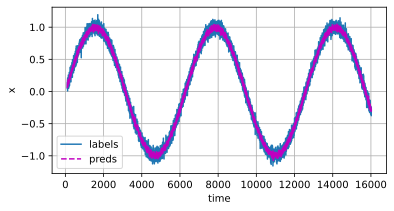

In [6]:
time_train = train_data.time.detach().cpu().numpy()
x_train = train_data.x.detach().cpu().numpy()

print(time_train.shape, x_train.shape, pred_train.shape)

d2l.plot(time_train, [x_train,pred_train], 'time', 'x', legend=['labels', 'preds'], figsize=(6,3))

(3980,) (3980,) (3980,)


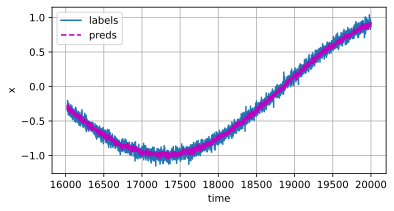

In [7]:
# Predicting data based on previous \tau true data
time_test = test_data.time.detach().cpu().numpy()
x_test = test_data.x.detach().cpu().numpy()

print(time_test.shape, x_test.shape, pred_test.shape)

d2l.plot(time_test, [x_test, pred_test], 'time', 'x', legend=['labels', 'preds'], figsize=(6,3))

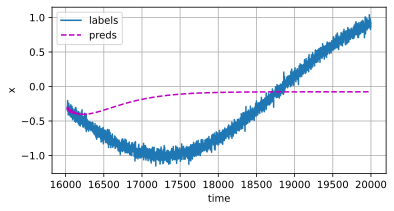

In [26]:
# Predicting data based on previous \tau prior predicted data
past_data = list(x_train)
k_step_pred = []

for i in range(len(time_test)):
    feature_list = past_data[-100:]    # print(type(feature_list))
    feature = torch.tensor(list(feature_list)).squeeze(-1).to(device)

    # print(type(past_data[0]))

    # print(feature.shape)
    y_hat = model(feature)

    past_data.append(y_hat.item())
    k_step_pred.append(y_hat.item())


d2l.plot(time_test, [x_test, k_step_pred], 'time', 'x', legend=['labels', 'preds'], figsize=(6,3))